## Import Libraries

In [10]:
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import numpy as np
import os

## Match Data

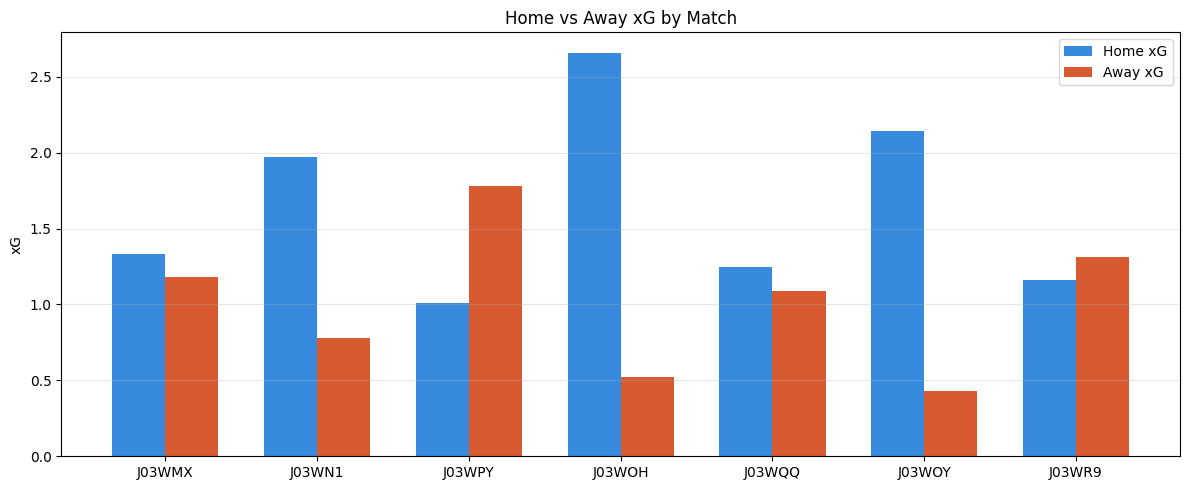

In [7]:
data = {
    'match_id': ['J03WMX','J03WN1','J03WPY','J03WOH','J03WQQ','J03WOY','J03WR9'],
    'home_xg':  [1.33, 1.97, 1.01, 2.66, 1.25, 2.14, 1.16],
    'away_xg':  [1.18, 0.78, 1.78, 0.52, 1.09, 0.43, 1.31],
    'result':   ['1:2','3:0','0:1','4:0','1:0','3:1','1:2']
}
df = pd.DataFrame(data)

x = np.arange(len(df))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, df['home_xg'], width, label='Home xG', color='#378ADD')
ax.bar(x + width/2, df['away_xg'], width, label='Away xG', color='#D85A30')

ax.set_xticks(x)
ax.set_xticklabels(df['match_id'], rotation=0)
ax.set_ylabel('xG')
ax.set_title('Home vs Away xG by Match')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
data = {
    'Match-ID': ['J03WMX', 'J03WN1', 'J03WPY', 'J03WOH', 'J03WQQ', 'J03WOY', 'J03WR9'],
    'Div':      ['1st', '1st', '2nd', '2nd', '2nd', '2nd', '2nd'],
    'Home':     ['1. FC Köln', 'VfL Bochum 1848', 'Fortuna Düsseldorf', 'Fortuna Düsseldorf', 'Fortuna Düsseldorf', 'Fortuna Düsseldorf', 'Fortuna Düsseldorf'],
    'Away':     ['FC Bayern München', 'Bayer 04 Leverkusen', '1. FC Nürnberg', 'SSV Jahn Regensburg', 'FC St. Pauli', 'F.C. Hansa Rostock', '1. FC Kaiserslautern'],
    'Result':   ['1:2', '3:0', '0:1', '4:0', '1:0', '3:1', '1:2'],
    'xG':       ['1.33:1.18', '1.97:0.78', '1.01:1.78', '2.66:0.52', '1.25:1.09', '2.14:0.43', '1.16:1.31'],
    'Date':     ['2023/05/27', '2023/05/27', '2022/10/15', '2022/08/26', '2022/11/05', '2022/09/10', '2022/11/11'],
    'NFrames':  [145967, 141561, 146211, 137214, 142345, 142536, 146810],
    'NEvents':  [1840, 1459, 1579, 1457, 1679, 1578, 1545]
}

df = pd.DataFrame(data)
df

,Match-ID,Div,Home,Away,Result,xG,Date,NFrames,NEvents
0,J03WMX,1st,1. FC Köln,FC Bayern München,1:2,1.33:1.18,2023/05/27,145967,1840
1,J03WN1,1st,VfL Bochum 1848,Bayer 04 Leverkusen,3:0,1.97:0.78,2023/05/27,141561,1459
2,J03WPY,2nd,Fortuna Düsseldorf,1. FC Nürnberg,0:1,1.01:1.78,2022/10/15,146211,1579
3,J03WOH,2nd,Fortuna Düsseldorf,SSV Jahn Regensburg,4:0,2.66:0.52,2022/08/26,137214,1457
4,J03WQQ,2nd,Fortuna Düsseldorf,FC St. Pauli,1:0,1.25:1.09,2022/11/05,142345,1679
5,J03WOY,2nd,Fortuna Düsseldorf,F.C. Hansa Rostock,3:1,2.14:0.43,2022/09/10,142536,1578
6,J03WR9,2nd,Fortuna Düsseldorf,1. FC Kaiserslautern,1:2,1.16:1.31,2022/11/11,146810,1545


In [16]:
data_path = "../data"  # your raw data folder
results = []

for match_id in os.listdir(data_path):
    match_dir = os.path.join(data_path, match_id)
    if not os.path.isdir(match_dir):
        continue

    for fname in os.listdir(match_dir):
        if "matchinformation" not in fname:
            continue

        tree = ET.parse(os.path.join(match_dir, fname))
        root = tree.getroot()

        for team in root.iter("Team"):
            team_name = team.attrib.get("TeamName")
            for player in team.iter("Player"):
                if "PlayingPosition" not in player.attrib:
                    results.append({
                        "match_id":   match_id,
                        "team":       team_name,
                        "person_id":  player.attrib.get("PersonId"),
                        "first_name": player.attrib.get("FirstName"),
                        "last_name":  player.attrib.get("LastName"),
                        "shirt_no":   player.attrib.get("ShirtNumber"),
                        "starting":   player.attrib.get("Starting")
                    })

df = pd.DataFrame(results)
df

""


In [13]:
os.getcwd()

'/Users/user/Desktop/Tonny/Football/2026-1-Big-Data-Processing-Platform-Termproject/src'